# Analyse des Accidents de la Route

In [1]:
import pandas as pd
import matplotlib.pyplot as plt

print("outils importes")

outils importes


In [2]:
df = pd.read_csv('rta_clean.csv', encoding='utf-8-sig', sep=';')
print(df.columns)

Index(['Time', 'Day_of_week', 'Sex_of_driver', 'Educational_level',
       'Vehicle_driver_relation', 'Driving_experience', 'Type_of_vehicle',
       'Owner_of_vehicle', 'Service_year_of_vehicle', 'Defect_of_vehicle',
       'Area_accident_occured', 'Lanes_or_Medians', 'Road_allignment',
       'Types_of_Junction', 'Road_surface_type', 'Road_surface_conditions',
       'Light_conditions', 'Weather_conditions', 'Type_of_collision',
       'Number_of_vehicles_involved', 'Number_of_casualties',
       'Vehicle_movement', 'Age_band_of_casualty', 'Pedestrian_movement',
       'Cause_of_accident', 'Accident_severity'],
      dtype='object')


In [3]:
# voir les premieres lignes
df.head()

,Time,Day_of_week,Sex_of_driver,Educational_level,Vehicle_driver_relation,Driving_experience,Type_of_vehicle,Owner_of_vehicle,Service_year_of_vehicle,Defect_of_vehicle,...,Light_conditions,Weather_conditions,Type_of_collision,Number_of_vehicles_involved,Number_of_casualties,Vehicle_movement,Age_band_of_casualty,Pedestrian_movement,Cause_of_accident,Accident_severity
0,17:02:00,Monday,Male,Above high school,Employee,1-2yr,Automobile,Owner,Above 10yr,No defect,...,Daylight,Normal,Collision with roadside-parked vehicles,2,2,Going straight,na,Not a Pedestrian,Moving Backward,Slight Injury
1,17:02:00,Monday,Male,Junior high school,Employee,Above 10yr,Public (> 45 seats),Owner,5-10yrs,No defect,...,Daylight,Normal,Vehicle with vehicle collision,2,2,Going straight,na,Not a Pedestrian,Overtaking,Slight Injury
2,17:02:00,Monday,Male,Junior high school,Employee,1-2yr,Lorry (41?100Q),Owner,unknown,No defect,...,Daylight,Normal,Collision with roadside objects,2,2,Going straight,31-50,Not a Pedestrian,Changing lane to the left,Serious Injury
3,01:06:00,Sunday,Male,Junior high school,Employee,5-10yr,Public (> 45 seats),Governmental,unknown,No defect,...,Darkness - lights lit,Normal,Vehicle with vehicle collision,2,2,Going straight,18-30,Not a Pedestrian,Changing lane to the right,Slight Injury
4,01:06:00,Sunday,Male,Junior high school,Employee,2-5yr,unknown,Owner,5-10yrs,No defect,...,Darkness - lights lit,Normal,Vehicle with vehicle collision,2,2,Going straight,na,Not a Pedestrian,Overtaking,Slight Injury


In [4]:
# valeurs manquantes
df.isnull().sum()

Time                           0
Day_of_week                    0
Sex_of_driver                  0
Educational_level              0
Vehicle_driver_relation        0
Driving_experience             0
Type_of_vehicle                0
Owner_of_vehicle               0
Service_year_of_vehicle        0
Defect_of_vehicle              0
Area_accident_occured          0
Lanes_or_Medians               0
Road_allignment                0
Types_of_Junction              0
Road_surface_type              0
Road_surface_conditions        0
Light_conditions               0
Weather_conditions             0
Type_of_collision              0
Number_of_vehicles_involved    0
Number_of_casualties           0
Vehicle_movement               0
Age_band_of_casualty           0
Pedestrian_movement            0
Cause_of_accident              0
Accident_severity              0
dtype: int64

In [5]:
# gravite des accidents
df['Accident_severity'].value_counts()

Accident_severity
Slight Injury     10415
Serious Injury     1743
Fatal injury        158
Name: count, dtype: int64

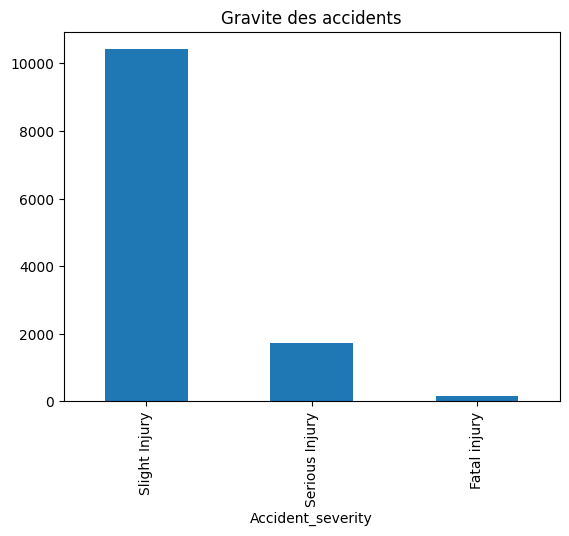

In [6]:
# graphique gravite des accidents
df['Accident_severity'].value_counts().plot(kind='bar')
plt.title('Gravite des accidents')
plt.show()

In [7]:
# accidents par jour de la semaine
df['Day_of_week'].value_counts()

Day_of_week
Friday       2041
Thursday     1851
Wednesday    1840
Tuesday      1770
Monday       1681
Saturday     1666
Sunday       1467
Name: count, dtype: int64

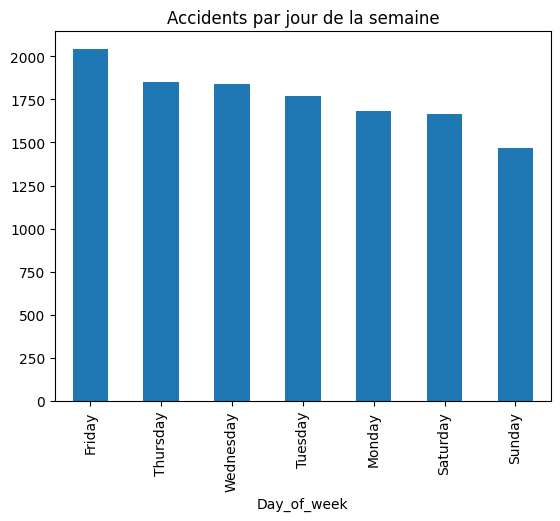

In [8]:
# graphique accidents par jour
df['Day_of_week'].value_counts().plot(kind='bar')
plt.title('Accidents par jour de la semaine')
plt.show()

In [9]:
# principales causes d'accidents
df[df['Cause_of_accident'] != 'Unknown']['Cause_of_accident'].value_counts().head(10)

Cause_of_accident
No distancing                           2263
Changing lane to the right              1808
Changing lane to the left               1473
Driving carelessly                      1402
No priority to vehicle                  1207
Moving Backward                         1137
No priority to pedestrian                721
Other                                    456
Overtaking                               430
Driving under the influence of drugs     340
Name: count, dtype: int64

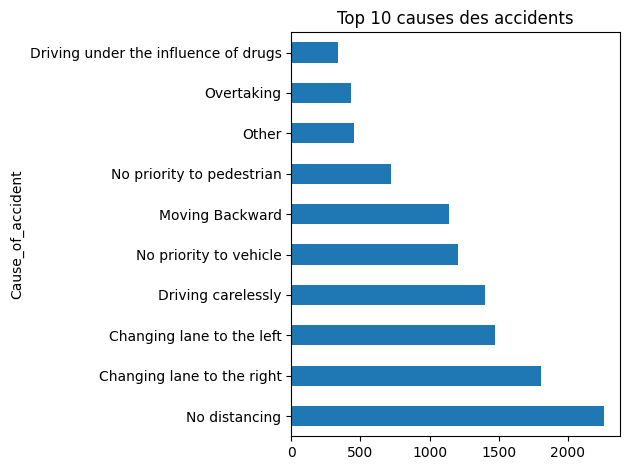

In [10]:
# graphique causes d'accidents
df[df['Cause_of_accident'] != 'Unknown']['Cause_of_accident'].value_counts().head(10).plot(kind='barh')
plt.title('Top 10 causes des accidents')
plt.tight_layout()
plt.show()

In [11]:
# conditions meteo lors des accidents
df[df['Weather_conditions'] != 'Unknown']['Weather_conditions'].value_counts()

Weather_conditions
Normal               10063
Raining               1331
Other                  296
Cloudy                 125
Windy                   98
Snow                    61
Raining and Windy       40
Fog or mist             10
Name: count, dtype: int64

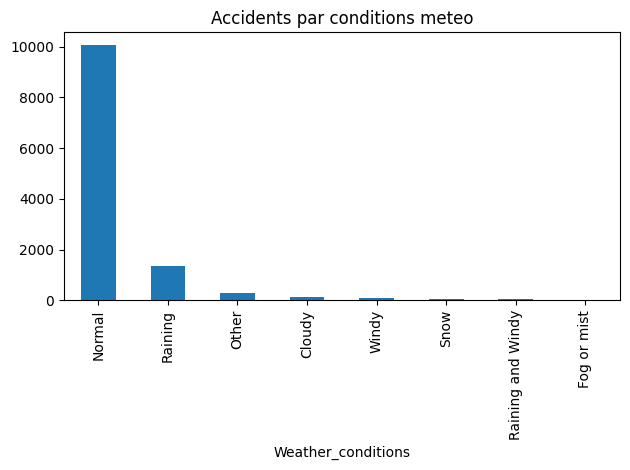

In [12]:
# graphique conditions meteo
df[df['Weather_conditions'] != 'Unknown']['Weather_conditions'].value_counts().plot(kind='bar')
plt.title('Accidents par conditions meteo')
plt.tight_layout()
plt.show()

In [13]:
# type de route lors des accidents
df[df['Road_surface_type'] != 'Unknown']['Road_surface_type'].value_counts()

Road_surface_type
Asphalt roads                       11296
Earth roads                           358
Gravel roads                          242
unknown                               172
Other                                 167
Asphalt roads with some distress       81
Name: count, dtype: int64

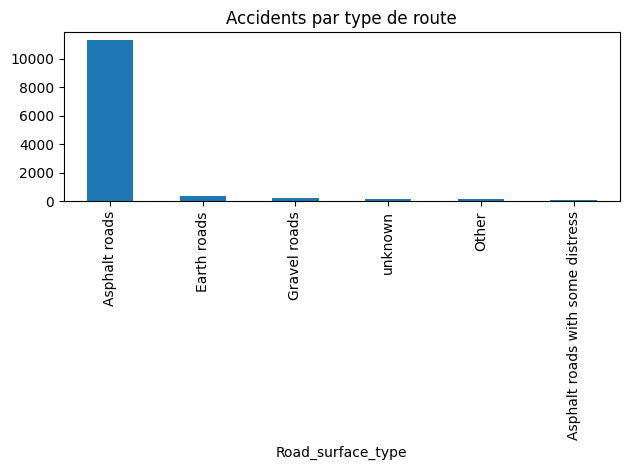

In [14]:
# graphique type de route
df[df['Road_surface_type'] != 'Unknown']['Road_surface_type'].value_counts().plot(kind='bar')
plt.title('Accidents par type de route')
plt.tight_layout()
plt.show()

In [15]:
# sauvegarder les donnees nettoyees
df.to_csv('rta_debutant.csv', index=False)
print("fichier sauvegarde")

fichier sauvegarde


# resumé

In [16]:
print(f"Total accidents : {len(df)}")
print(f"Accidents mortels : {len(df[df['Accident_severity'] == 'Fatal injury'])}")
print(f"Jour le plus dangereux : {df['Day_of_week'].value_counts().idxmax()}")
print(f"Principale cause : {df[df['Cause_of_accident'] != 'Unknown']['Cause_of_accident'].value_counts().idxmax()}")

Total accidents : 12316
Accidents mortels : 158
Jour le plus dangereux : Friday
Principale cause : No distancing
